# Entregable 4: Evaluación Robusta y Análisis de Trade-offs

| | |
|---|---|
| **Institución** | Instituto Tecnológico y de Estudios Superiores de Monterrey |
| **Curso** | TI3005B.101 — Trasformación digital de organizaciones de la sociedad civil |
| **Fecha** | 3 de marzo de 2026 |

**Autores:**
- Arturo Barrios Mendoza
- Lucio Arturo Reyes Castillo
- Mariana Balderrábano Aguilar
- Lizbeth Islas Becerril
- Maximiliano De La Cruz Lima
- Carlos Alberto Zamudio Velázquez
- Rafael Soto Padilla

---

Este notebook evalúa los resultados de la optimización multi-objetivo (NSGA-II) del simulador de robots de almacén,
compara con el baseline y analiza trade-offs explícitos entre las métricas de desempeño.

In [ ]:
import json
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from matplotlib.lines import Line2D

sns.set_theme(style="whitegrid")
plt.rcParams["figure.dpi"] = 120
plt.rcParams["figure.figsize"] = (10, 6)

ROOT = Path("..")  # repo root relative to notebooks/

# Paleta constante por escenario
SCENARIO_COLORS = {
    "burst": "#e74c3c",
    "nonburst": "#3498db",
    "baseline": "#8e44ad",
}

print("Setup completo.")

In [42]:
# --- Carga de datos ---

# Baseline
with open(ROOT / "outputs" / "seed42" / "metrics.json") as f:
    bl_raw = json.load(f)

# Configuración conocida del baseline (de config + archivos de salida)
bl_raw["width"] = 328
bl_raw["height"] = 182
bl_raw["stations"] = 17
bl_raw["orders_burst"] = False
bl_raw["orders_count"] = bl_raw["total_orders"]
bl_raw["completion_pct"] = bl_raw["completed_orders"] / bl_raw["total_orders"] * 100

baseline = pd.DataFrame([bl_raw])

# Pareto front
pareto = pd.read_csv(ROOT / "outputs" / "moop" / "pareto_front.csv")

print(f"Baseline: {len(baseline)} fila, Pareto: {len(pareto)} soluciones")
print(f"Columnas Pareto: {list(pareto.columns)}")
pareto.head()

Baseline: 1 fila, Pareto: 40 soluciones
Columnas Pareto: ['seed', 'robots', 'width', 'stations', 'orders_burst', 'height', 'orders_count', 'deadlocks', 'throughput_per_1000_ticks', 'completed_orders', 'avg_order_time_ticks', 'completion_pct', 'total_distance_cells', 'high_contention_events']


,seed,robots,width,stations,orders_burst,height,orders_count,deadlocks,throughput_per_1000_ticks,completed_orders,avg_order_time_ticks,completion_pct,total_distance_cells,high_contention_events
0,44,50,328,17,False,182,600,0,117.0,585,2507.62,97.5,234045,4382
1,44,50,353,13,False,169,600,0,120.0,600,2616.60,100.0,238303,441
2,44,50,328,15,False,182,600,0,119.6,598,2574.95,99.7,236519,551
3,44,50,327,9,False,183,600,0,118.4,592,2534.68,98.7,235808,644
4,44,50,327,6,False,183,600,0,119.2,596,2561.68,99.3,235588,1084


In [43]:
# --- Métricas derivadas ---

def add_derived(df):
    """Agrega columnas derivadas de eficiencia."""
    df["throughput_norm"] = df["throughput_per_1000_ticks"] / df["robots"]
    df["distance_per_order"] = df["total_distance_cells"] / df["completed_orders"]
    df["contention_per_order"] = df["high_contention_events"] / df["completed_orders"]
    return df

pareto = add_derived(pareto)
baseline = add_derived(baseline)

print("Métricas derivadas agregadas:")
print(f"  throughput_norm, distance_per_order, contention_per_order")
pareto[["throughput_norm", "distance_per_order", "contention_per_order"]].describe().round(2)

Métricas derivadas agregadas:
  throughput_norm, distance_per_order, contention_per_order


,throughput_norm,distance_per_order,contention_per_order
count,40.00,40.00,40.00
mean,2.27,401.81,2.91
std,0.20,6.93,3.59
min,1.89,395.28,0.71
25%,2.35,398.02,0.72
50%,2.36,398.98,1.20
75%,2.40,400.33,4.11
max,2.40,417.54,16.88


In [ ]:
# --- Clasificación de escenarios ---

def classify_scenario(row):
    if row["orders_burst"] == True or str(row["orders_burst"]).strip().lower() == "true":
        return "burst"
    return "nonburst"

pareto["scenario"] = pareto.apply(classify_scenario, axis=1)
SCENARIO_ORDER = sorted(pareto["scenario"].unique().tolist())

print("Distribución de escenarios:")
print(pareto["scenario"].value_counts().to_string())
print(f"\nSCENARIO_ORDER = {SCENARIO_ORDER}")

In [ ]:
# --- Contexto y diferencias metodológicas ---

bl_ticks = int(baseline["final_tick"].iloc[0])
moop_ticks = 10000  # from config eval_ticks

context = pd.DataFrame({
    "Parámetro": ["Seed", "Ticks simulados", "Robots", "Grid", "Estaciones",
                  "Burst", "Pedidos"],
    "Baseline": [
        int(baseline["seed"].iloc[0]),
        bl_ticks,
        int(baseline["robots"].iloc[0]),
        f"{int(baseline['width'].iloc[0])}×{int(baseline['height'].iloc[0])} (fijo)",
        int(baseline["stations"].iloc[0]),
        "No",
        int(baseline["total_orders"].iloc[0]),
    ],
    "MOOP (NSGA-II)": [
        int(pareto["seed"].iloc[0]),
        moop_ticks,
        f"{int(pareto['robots'].min())}–{int(pareto['robots'].max())}",
        f"Área fija=60,000, aspecto variable ({int(pareto['width'].min())}–{int(pareto['width'].max())})",
        f"{int(pareto['stations'].min())}–{int(pareto['stations'].max())} (variable)",
        "Variable (True/False)",
        int(pareto["orders_count"].iloc[0]),
    ],
})

display(context.set_index("Parámetro"))

if bl_ticks == moop_ticks:
    print(f"\n✅ Ambos usan {bl_ticks:,} ticks → comparación de valores absolutos es VÁLIDA.")
    print("   La diferencia principal es el número de robots y la configuración de grid.")
else:
    print(f"\n⚠️ Baseline usa {bl_ticks:,} ticks vs MOOP {moop_ticks:,} ticks.")
    print("   Comparación directa de valores absolutos requiere precaución.")

In [45]:
# --- Estadísticas descriptivas por escenario ---

metrics_cols = [
    "throughput_per_1000_ticks", "completion_pct", "avg_order_time_ticks",
    "high_contention_events", "total_distance_cells", "deadlocks",
    "throughput_norm", "distance_per_order", "contention_per_order",
]

desc = (
    pareto.groupby("scenario")[metrics_cols]
    .agg(["mean", "std", "min", "median", "max"])
)

# Mostrar transpuesto para legibilidad
with pd.option_context("display.max_columns", None, "display.max_rows", None,
                       "display.float_format", "{:.2f}".format):
    display(desc.T)

# --- Interpretación automática ---
print("\n" + "=" * 70)
print("INTERPRETACIÓN DE ESTADÍSTICAS DESCRIPTIVAS")
print("=" * 70)

for scenario in SCENARIO_ORDER:
    subset = pareto[pareto["scenario"] == scenario]
    if len(subset) == 0:
        continue
    tp_std = subset["throughput_per_1000_ticks"].std() if len(subset) > 1 else 0
    cp_range = subset["completion_pct"].max() - subset["completion_pct"].min()
    hc_cv = (subset["high_contention_events"].std() / subset["high_contention_events"].mean()
             if len(subset) > 1 and subset["high_contention_events"].mean() > 0 else 0)

    print(f"\n  {scenario} ({len(subset)} soluciones):")
    if tp_std < 1:
        print(f"    → Throughput MUY ESTABLE (std={tp_std:.2f}): soluciones altamente consistentes")
    else:
        print(f"    → Throughput variable (std={tp_std:.2f}): hay dispersión entre soluciones")
    if cp_range < 2:
        print(f"    → Completud homogénea (rango={cp_range:.1f}pp)")
    else:
        print(f"    → Completud heterogénea (rango={cp_range:.1f}pp)")
    if hc_cv > 0.5:
        print(f"    → Contención IMPREDECIBLE (CV={hc_cv:.2f}): alta sensibilidad a configuración")
    elif hc_cv > 0:
        print(f"    → Contención moderadamente estable (CV={hc_cv:.2f})")
    else:
        print(f"    → Contención: dato único, no se puede evaluar variabilidad")

scenario                             burst  nonburst_narrow  nonburst_wide  \
throughput_per_1000_ticks mean       95.38           118.10         119.82   
                          std         0.51             0.83           0.06   
                          min        94.60           117.00         119.80   
                          median     95.40           117.80         119.80   
                          max        96.00           119.60         120.00   
completion_pct            mean       79.48            98.41          99.82   
                          std         0.43             0.70           0.06   
                          min        78.80            97.50          99.80   
                          median     79.50            98.20          99.80   
                          max        80.00            99.70         100.00   
avg_order_time_ticks      mean     1081.84          2531.45        2613.25   
                          std        16.07            22.05           1.06   
                          min      1064.25          2507.62        2612.94   
                          median   1081.08          2521.71        2612.94   
                          max      1104.69          2574.95        2616.60   
high_contention_events    mean     3132.22          1549.67         429.17   
                          std      2707.78          1051.40           3.86   
                          min       431.00           551.00         427.00   
                          median   2576.00          1065.50         428.00   
                          max      7986.00          4382.00         441.00   
total_distance_cells      mean   197499.67        235272.61      238403.83   
                          std      1712.81           697.44          31.75   
                          min    195582.00        234045.00      238303.00   
                          median 197224.00        235379.50      238413.00   
                          max    199879.00        236519.00      238413.00   
deadlocks                 mean        0.00             0.00           0.00   
                          std         0.00             0.00           0.00   
                          min         0.00             0.00           0.00   
                          median      0.00             0.00           0.00   
                          max         0.00             0.00           0.00   
throughput_norm           mean        1.91             2.36           2.40   
                          std         0.01             0.02           0.00   
                          min         1.89             2.34           2.40   
                          median      1.91             2.36           2.40   
                          max         1.92             2.39           2.40   
distance_per_order        mean      414.14           398.44         397.95   
                          std         2.12             1.99           0.24   
                          min       411.32           395.28         397.17   
                          median    413.43           399.66         398.02   
                          max       417.54           400.66         398.02   
contention_per_order      mean        6.59             2.63           0.72   
                          std         5.73             1.80           0.01   
                          min         0.90             0.92           0.71   
                          median      5.40             1.79           0.71   
                          max        16.88             7.49           0.73   

scenario                           outlier  
throughput_per_1000_ticks mean      119.80  
                          std          NaN  
                          min       119.80  
                          median    119.80  
                          max       119.80  
completion_pct            mean       99.80  
                          std          NaN  
                          min        99.80  
      


INTERPRETACIÓN DE ESTADÍSTICAS DESCRIPTIVAS

  burst (9 soluciones):
    → Throughput MUY ESTABLE (std=0.51): soluciones altamente consistentes
    → Completud homogénea (rango=1.2pp)
    → Contención IMPREDECIBLE (CV=0.86): alta sensibilidad a configuración

  nonburst_narrow (18 soluciones):
    → Throughput MUY ESTABLE (std=0.83): soluciones altamente consistentes
    → Completud heterogénea (rango=2.2pp)
    → Contención IMPREDECIBLE (CV=0.68): alta sensibilidad a configuración

  nonburst_wide (12 soluciones):
    → Throughput MUY ESTABLE (std=0.06): soluciones altamente consistentes
    → Completud homogénea (rango=0.2pp)
    → Contención moderadamente estable (CV=0.01)

  outlier (1 soluciones):
    → Throughput MUY ESTABLE (std=0.00): soluciones altamente consistentes
    → Completud homogénea (rango=0.0pp)
    → Contención: dato único, no se puede evaluar variabilidad


In [ ]:
# --- Box plots por escenario ---

plot_metrics = [
    ("throughput_per_1000_ticks", "Throughput (pedidos/1000 ticks)"),
    ("completion_pct", "Completud (%)"),
    ("avg_order_time_ticks", "Tiempo promedio pedido (ticks)"),
    ("high_contention_events", "Eventos de alta contención"),
    ("total_distance_cells", "Distancia total (celdas)"),
    ("deadlocks", "Deadlocks"),
]

fig, axes = plt.subplots(2, 3, figsize=(16, 10))
fig.suptitle("Distribución de métricas por escenario", fontsize=14, fontweight="bold")

palette = {s: SCENARIO_COLORS.get(s, "#95a5a6") for s in SCENARIO_ORDER}

for ax, (col, label) in zip(axes.flat, plot_metrics):
    sns.boxplot(
        data=pareto, x="scenario", y=col, hue="scenario", order=SCENARIO_ORDER,
        palette=palette, ax=ax, width=0.6, legend=False,
    )
    # Baseline reference
    if col in baseline.columns:
        bl_val = baseline[col].iloc[0]
        ax.axhline(bl_val, color=SCENARIO_COLORS["baseline"], ls="--", lw=1.5, alpha=0.7)
        ax.text(ax.get_xlim()[1] * 0.98, bl_val, f" BL={bl_val:.0f}", va="bottom",
                ha="right", fontsize=7, color=SCENARIO_COLORS["baseline"])
    ax.set_ylabel(label, fontsize=9)
    ax.set_xlabel("")
    ax.tick_params(axis="x", rotation=20, labelsize=8)

plt.tight_layout()
plt.show()

In [47]:
# --- Tabla comparativa: mean ± std por escenario + deltas vs baseline ---

compare_cols = [
    "throughput_per_1000_ticks", "completion_pct", "avg_order_time_ticks",
    "high_contention_events", "total_distance_cells",
    "throughput_norm", "distance_per_order", "contention_per_order",
]

rows = []
for scenario in SCENARIO_ORDER:
    subset = pareto[pareto["scenario"] == scenario]
    row = {"Escenario": scenario, "n": len(subset)}
    for col in compare_cols:
        m, s = subset[col].mean(), subset[col].std()
        row[col] = f"{m:.1f} ± {s:.1f}" if s > 0.01 else f"{m:.1f}"
    rows.append(row)

# Agregar baseline como referencia
bl_row = {"Escenario": "baseline", "n": 1}
for col in compare_cols:
    bl_row[col] = f"{baseline[col].iloc[0]:.1f}"
rows.append(bl_row)

compare_df = pd.DataFrame(rows).set_index("Escenario")
display(compare_df)

# --- Tabla de deltas porcentuales vs baseline ---
print("\n" + "=" * 70)
print("CAMBIO PORCENTUAL vs BASELINE (métricas normalizadas)")
print("=" * 70)
print("(Positivo = MOOP mayor que baseline, Negativo = MOOP menor)\n")

norm_cols = ["throughput_norm", "distance_per_order", "contention_per_order"]
norm_labels = ["Throughput/robot", "Distancia/pedido", "Contención/pedido"]

delta_rows = []
for scenario in SCENARIO_ORDER:
    subset = pareto[pareto["scenario"] == scenario]
    row = {"Escenario": scenario}
    for col, lbl in zip(norm_cols, norm_labels):
        bl_val = baseline[col].iloc[0]
        moop_val = subset[col].mean()
        delta = (moop_val - bl_val) / bl_val * 100
        row[lbl] = f"{delta:+.1f}%"
    delta_rows.append(row)

delta_df = pd.DataFrame(delta_rows).set_index("Escenario")
display(delta_df)

# Interpretación
bl_tn = baseline["throughput_norm"].iloc[0]
bl_cpo = baseline["contention_per_order"].iloc[0]
for scenario in SCENARIO_ORDER:
    subset = pareto[pareto["scenario"] == scenario]
    if len(subset) == 0:
        continue
    moop_tn = subset["throughput_norm"].mean()
    moop_cpo = subset["contention_per_order"].mean()
    delta_tn = (moop_tn - bl_tn) / bl_tn * 100
    delta_cpo = (moop_cpo - bl_cpo) / bl_cpo * 100

    print(f"\n  {scenario}:")
    if delta_tn > 0:
        print(f"    → Throughput/robot: +{delta_tn:.1f}% vs baseline → MOOP es más eficiente por robot")
    else:
        print(f"    → Throughput/robot: {delta_tn:.1f}% vs baseline → MOOP es menos eficiente por robot")
    print(f"    → Contención/pedido: {delta_cpo:+.1f}% vs baseline → {'MEJORA significativa' if delta_cpo < -50 else 'Cambio moderado'}")

,n,throughput_per_1000_ticks,completion_pct,avg_order_time_ticks,high_contention_events,total_distance_cells,throughput_norm,distance_per_order,contention_per_order
Escenario,,,,,,,,,
burst,9,95.4 ± 0.5,79.5 ± 0.4,1081.8 ± 16.1,3132.2 ± 2707.8,197499.7 ± 1712.8,1.9 ± 0.0,414.1 ± 2.1,6.6 ± 5.7
nonburst_narrow,18,118.1 ± 0.8,98.4 ± 0.7,2531.4 ± 22.1,1549.7 ± 1051.4,235272.6 ± 697.4,2.4 ± 0.0,398.4 ± 2.0,2.6 ± 1.8
nonburst_wide,12,119.8 ± 0.1,99.8 ± 0.1,2613.2 ± 1.1,429.2 ± 3.9,238403.8 ± 31.8,2.4,397.9 ± 0.2,0.7
outlier,1,119.8,99.8,2612.9,633.0,238284.0,2.4,397.8,1.1
baseline,1,59.7,99.5,2556.8,19525.0,235828.0,1.2,395.0,32.7



CAMBIO PORCENTUAL vs BASELINE (métricas normalizadas)
(Positivo = MOOP mayor que baseline, Negativo = MOOP menor)



,Throughput/robot,Distancia/pedido,Contención/pedido
Escenario,,,
burst,+59.8%,+4.8%,-79.8%
nonburst_narrow,+97.8%,+0.9%,-91.9%
nonburst_wide,+100.7%,+0.7%,-97.8%
outlier,+100.7%,+0.7%,-96.8%



  burst:
    → Throughput/robot: +59.8% vs baseline → MOOP es más eficiente por robot
    → Contención/pedido: -79.8% vs baseline → MEJORA significativa

  nonburst_narrow:
    → Throughput/robot: +97.8% vs baseline → MOOP es más eficiente por robot
    → Contención/pedido: -91.9% vs baseline → MEJORA significativa

  nonburst_wide:
    → Throughput/robot: +100.7% vs baseline → MOOP es más eficiente por robot
    → Contención/pedido: -97.8% vs baseline → MEJORA significativa

  outlier:
    → Throughput/robot: +100.7% vs baseline → MOOP es más eficiente por robot
    → Contención/pedido: -96.8% vs baseline → MEJORA significativa


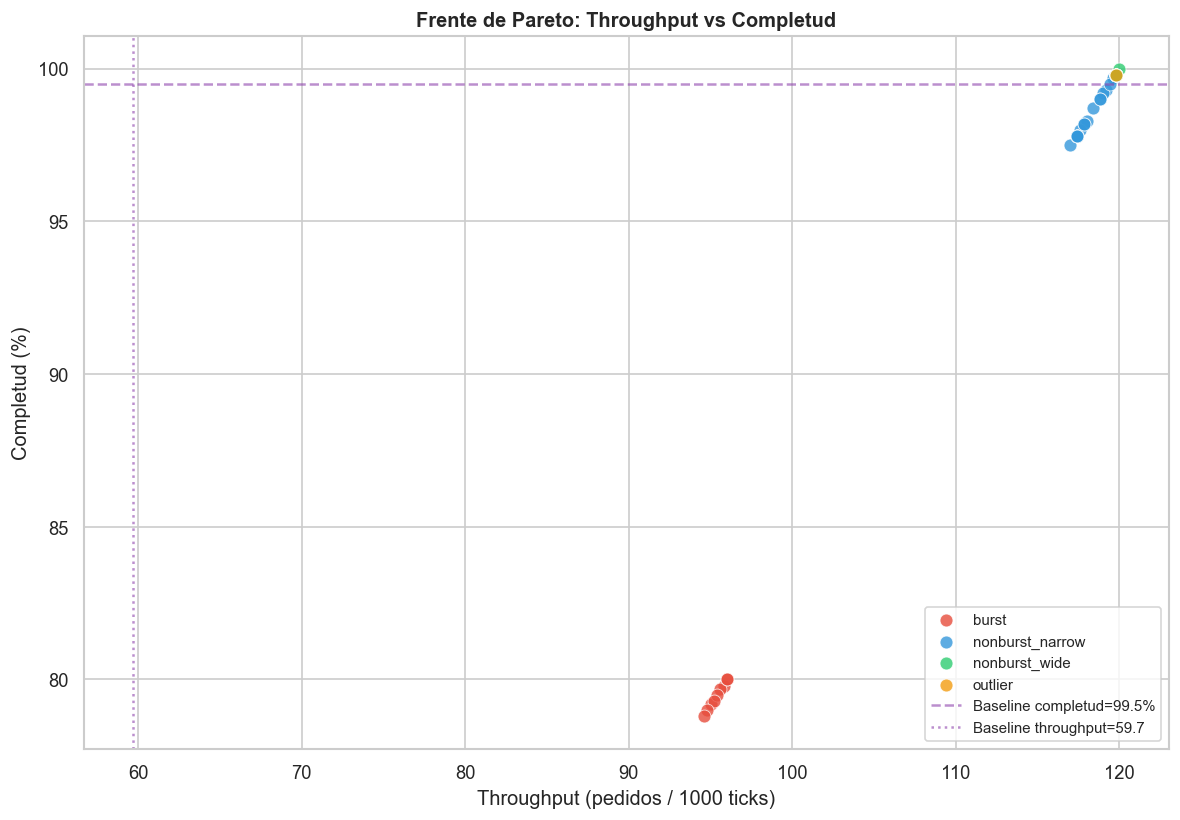

In [48]:
# --- Frente de Pareto: Throughput vs Completud ---

fig, ax = plt.subplots(figsize=(10, 7))

for scenario in SCENARIO_ORDER:
    subset = pareto[pareto["scenario"] == scenario]
    ax.scatter(
        subset["throughput_per_1000_ticks"], subset["completion_pct"],
        c=SCENARIO_COLORS[scenario], label=scenario, s=60, alpha=0.8,
        edgecolors="white", linewidth=0.5,
    )

# Referencia baseline
bl_tp = baseline["throughput_per_1000_ticks"].iloc[0]
bl_cp = baseline["completion_pct"].iloc[0]
ax.axhline(bl_cp, color=SCENARIO_COLORS["baseline"], ls="--", alpha=0.6, label=f"Baseline completud={bl_cp:.1f}%")
ax.axvline(bl_tp, color=SCENARIO_COLORS["baseline"], ls=":", alpha=0.6, label=f"Baseline throughput={bl_tp:.1f}")

ax.set_xlabel("Throughput (pedidos / 1000 ticks)")
ax.set_ylabel("Completud (%)")
ax.set_title("Frente de Pareto: Throughput vs Completud", fontweight="bold")
ax.legend(fontsize=9)
plt.tight_layout()
plt.show()

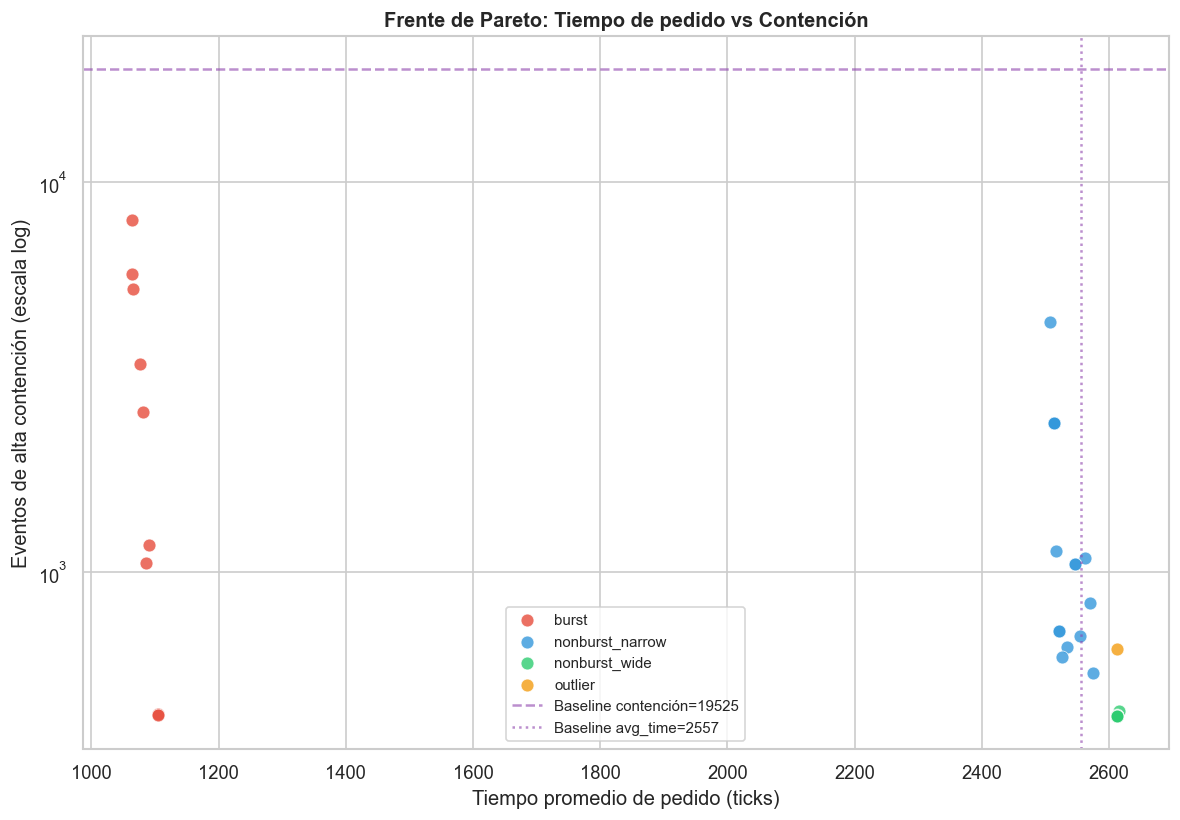

In [49]:
# --- Frente de Pareto: Tiempo de pedido vs Contención ---

fig, ax = plt.subplots(figsize=(10, 7))

for scenario in SCENARIO_ORDER:
    subset = pareto[pareto["scenario"] == scenario]
    ax.scatter(
        subset["avg_order_time_ticks"], subset["high_contention_events"],
        c=SCENARIO_COLORS[scenario], label=scenario, s=60, alpha=0.8,
        edgecolors="white", linewidth=0.5,
    )

# Referencia baseline
bl_at = baseline["avg_order_time_ticks"].iloc[0]
bl_hc = baseline["high_contention_events"].iloc[0]
ax.axhline(bl_hc, color=SCENARIO_COLORS["baseline"], ls="--", alpha=0.6, label=f"Baseline contenci\u00f3n={bl_hc}")
ax.axvline(bl_at, color=SCENARIO_COLORS["baseline"], ls=":", alpha=0.6, label=f"Baseline avg_time={bl_at:.0f}")

ax.set_xlabel("Tiempo promedio de pedido (ticks)")
ax.set_ylabel("Eventos de alta contenci\u00f3n (escala log)")
ax.set_yscale("log")
ax.set_title("Frente de Pareto: Tiempo de pedido vs Contenci\u00f3n", fontweight="bold")
ax.legend(fontsize=9)
plt.tight_layout()
plt.show()

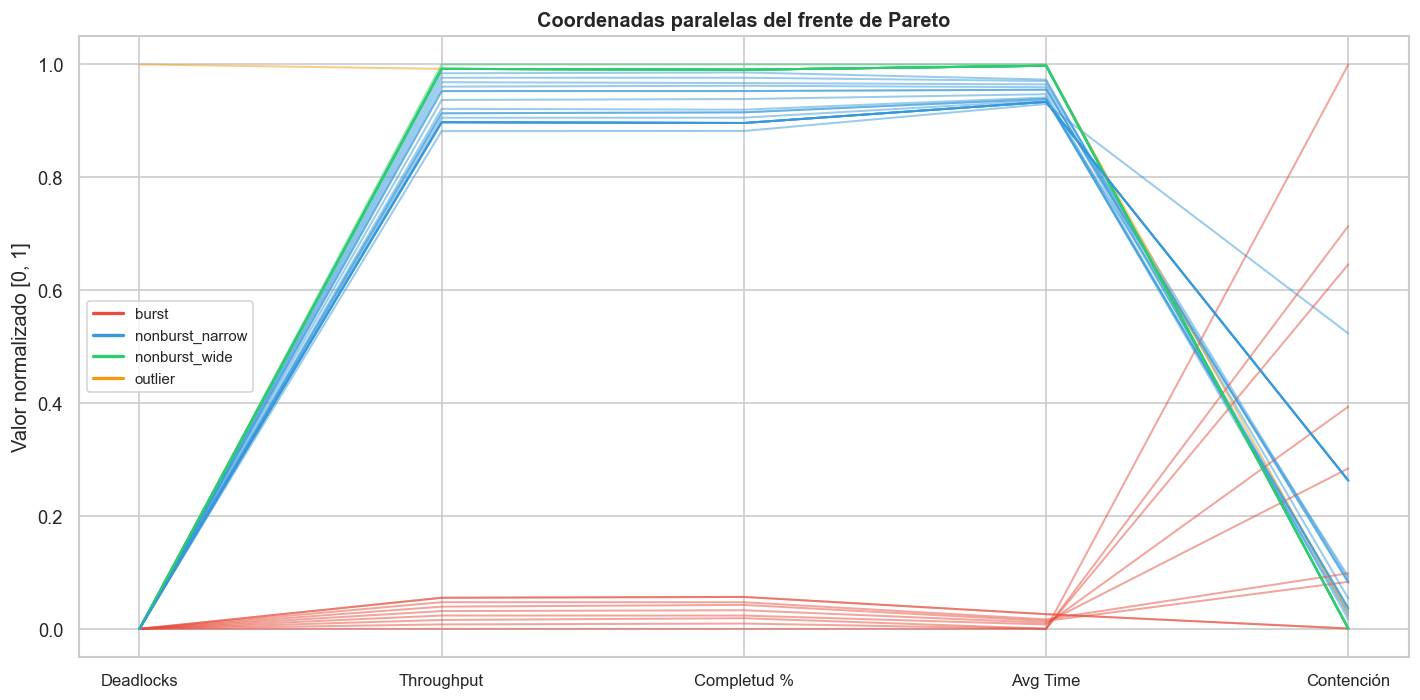

In [50]:
# --- Coordenadas paralelas ---

par_cols = ["deadlocks", "throughput_per_1000_ticks", "completion_pct",
            "avg_order_time_ticks", "high_contention_events"]
par_labels = ["Deadlocks", "Throughput", "Completud %", "Avg Time", "Contenci\u00f3n"]

# Normalizar a [0, 1]
normed = pareto[par_cols].copy()
for col in par_cols:
    cmin, cmax = normed[col].min(), normed[col].max()
    if cmax > cmin:
        normed[col] = (normed[col] - cmin) / (cmax - cmin)
    else:
        normed[col] = 0.5

fig, ax = plt.subplots(figsize=(12, 6))
x = np.arange(len(par_cols))

for idx, row in normed.iterrows():
    scenario = pareto.loc[idx, "scenario"]
    ax.plot(x, row.values, color=SCENARIO_COLORS[scenario], alpha=0.5, linewidth=1.2)

ax.set_xticks(x)
ax.set_xticklabels(par_labels, fontsize=10)
ax.set_ylabel("Valor normalizado [0, 1]")
ax.set_title("Coordenadas paralelas del frente de Pareto", fontweight="bold")

handles = [Line2D([0], [0], color=SCENARIO_COLORS[s], lw=2, label=s) for s in SCENARIO_ORDER]
ax.legend(handles=handles, fontsize=9)
plt.tight_layout()
plt.show()

In [ ]:
# --- Trade-off 1: Burst vs Completud ---

tradeoff1 = pareto.groupby("scenario")[["avg_order_time_ticks", "completion_pct"]].mean()
plot_scenarios = [s for s in ["burst", "nonburst_narrow", "nonburst_wide"] if s in tradeoff1.index]
tradeoff1 = tradeoff1.loc[plot_scenarios]

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 5))

colors = [SCENARIO_COLORS[s] for s in tradeoff1.index]

# Tiempo promedio
tradeoff1["avg_order_time_ticks"].plot.bar(ax=ax1, color=colors, edgecolor="white")
bl_at = baseline["avg_order_time_ticks"].iloc[0]
ax1.axhline(bl_at, color=SCENARIO_COLORS["baseline"], ls="--", lw=1.5,
            label=f"Baseline = {bl_at:.0f}")
ax1.set_ylabel("Tiempo promedio de pedido (ticks)")
ax1.set_title("Tiempo promedio por escenario")
ax1.tick_params(axis="x", rotation=20)
ax1.legend(fontsize=8)

# Completud
tradeoff1["completion_pct"].plot.bar(ax=ax2, color=colors, edgecolor="white")
bl_cp = baseline["completion_pct"].iloc[0]
ax2.axhline(bl_cp, color=SCENARIO_COLORS["baseline"], ls="--", lw=1.5,
            label=f"Baseline = {bl_cp:.1f}%")
ax2.set_ylabel("Completud (%)")
ax2.set_title("Completud por escenario")
ax2.set_ylim(70, 102)
ax2.tick_params(axis="x", rotation=20)
ax2.legend(fontsize=8)

fig.suptitle("Trade-off 1: Velocidad vs Completud", fontsize=13, fontweight="bold")
plt.tight_layout()
plt.show()

In [ ]:
# --- Interpretación Trade-off 1 ---

burst_time = tradeoff1.loc["burst", "avg_order_time_ticks"]
burst_cp = tradeoff1.loc["burst", "completion_pct"]

nb_scenarios = [s for s in ["nonburst_narrow", "nonburst_wide"] if s in tradeoff1.index]
nb_time = tradeoff1.loc[nb_scenarios, "avg_order_time_ticks"].mean()
nb_cp = tradeoff1.loc[nb_scenarios, "completion_pct"].mean()

bl_time = baseline["avg_order_time_ticks"].iloc[0]
bl_cp = baseline["completion_pct"].iloc[0]

reduccion_pct = (1 - burst_time / nb_time) * 100
perdida_pp = nb_cp - burst_cp

print("=" * 70)
print("ANÁLISIS TRADE-OFF 1: Velocidad vs Completud")
print("=" * 70)
print(f"\n  Tiempo promedio de pedido:")
print(f"    Burst:       {burst_time:,.0f} ticks")
print(f"    Non-burst:   {nb_time:,.0f} ticks")
for s in nb_scenarios:
    print(f"      {s}: {tradeoff1.loc[s, 'avg_order_time_ticks']:,.0f} ticks")
print(f"    Baseline:    {bl_time:,.0f} ticks")
print(f"    Reducción burst vs non-burst: {reduccion_pct:.0f}%")
print(f"\n  Completud:")
print(f"    Burst:       {burst_cp:.1f}%")
print(f"    Non-burst:   {nb_cp:.1f}%")
for s in nb_scenarios:
    print(f"      {s}: {tradeoff1.loc[s, 'completion_pct']:.1f}%")
print(f"    Baseline:    {bl_cp:.1f}%")
print(f"    Pérdida burst vs non-burst: {perdida_pp:.1f} puntos porcentuales")
print(f"\n  CONCLUSIÓN:")
print(f"    El burst sacrifica ~{perdida_pp:.0f}pp de completud para ganar ~{reduccion_pct:.0f}% de velocidad.")
print(f"    Esto ocurre porque con ticks limitados, los pedidos en ráfaga se procesan")
print(f"    rápido pero muchos quedan sin completar al final de la ventana.")

In [ ]:
# --- Trade-off 2: Variabilidad de contención ---

burst_df = pareto[pareto["scenario"] == "burst"].copy()
nonburst_df = pareto[pareto["scenario"] == "nonburst"].copy()

fig, ax = plt.subplots(figsize=(12, 5))

burst_sorted = burst_df.sort_values("high_contention_events").reset_index(drop=True)
ax.bar(
    range(len(burst_sorted)), burst_sorted["high_contention_events"],
    color=SCENARIO_COLORS["burst"], label="Burst", edgecolor="white",
)

if len(nonburst_df) > 0:
    nb_mean = nonburst_df["high_contention_events"].mean()
    ax.axhline(nb_mean, color=SCENARIO_COLORS["nonburst"], ls="--", lw=2,
               label=f"Non-burst promedio = {nb_mean:,.0f}")

bl_hc = baseline["high_contention_events"].iloc[0]
ax.axhline(bl_hc, color=SCENARIO_COLORS["baseline"], ls=":", lw=2,
           label=f"Baseline = {bl_hc:,}")

ax.set_xlabel("Solución burst (ordenada)")
ax.set_ylabel("Eventos de alta contención")
ax.set_title("Trade-off 2: Variabilidad de contención en modo burst", fontweight="bold")
ax.legend()

plt.tight_layout()
plt.show()

# --- Análisis cuantitativo ---
cv_burst = burst_df["high_contention_events"].std() / burst_df["high_contention_events"].mean() if len(burst_df) > 1 else 0
cv_nonburst = nonburst_df["high_contention_events"].std() / nonburst_df["high_contention_events"].mean() if len(nonburst_df) > 1 else 0

print("--- Variabilidad de contención ---")
print(f"  Burst:     rango [{burst_df['high_contention_events'].min():,} – {burst_df['high_contention_events'].max():,}], CV = {cv_burst:.2f}")
if len(nonburst_df) > 0:
    print(f"  Non-burst: rango [{nonburst_df['high_contention_events'].min():,} – {nonburst_df['high_contention_events'].max():,}], CV = {cv_nonburst:.2f}")
print(f"  Baseline:  {bl_hc:,} eventos")
if cv_nonburst > 0:
    print(f"\n  → Burst tiene {cv_burst/cv_nonburst:.1f}x {'más' if cv_burst > cv_nonburst else 'menos'} variabilidad que non-burst")

In [ ]:
# --- Interpretación Trade-off 2 ---

burst_hc_min = burst_df["high_contention_events"].min()
burst_hc_max = burst_df["high_contention_events"].max()
burst_hc_mean = burst_df["high_contention_events"].mean()
nb_hc_mean = nonburst_df["high_contention_events"].mean()
bl_hc = baseline["high_contention_events"].iloc[0]

print("=" * 70)
print("ANÁLISIS TRADE-OFF 2: Predictibilidad operativa")
print("=" * 70)
print(f"\n  Contención en burst:")
print(f"    Rango:    [{burst_hc_min:,} – {burst_hc_max:,}] eventos")
print(f"    Media:    {burst_hc_mean:,.0f}")
print(f"    CV:       {cv_burst:.2f}")
print(f"\n  Contención en non-burst:")
print(f"    Media:    {nb_hc_mean:,.0f}")
print(f"    CV:       {cv_nonburst:.2f}")
print(f"\n  Baseline:  {bl_hc:,} eventos")
print(f"\n  CONCLUSIÓN:")
print(f"    El burst tiene {cv_burst/cv_nonburst:.1f}x más variabilidad en contención que non-burst.")
print(f"    Soluciones burst van de {burst_hc_min:,} a {burst_hc_max:,} eventos ({burst_hc_max/burst_hc_min:.1f}x rango),")
print(f"    lo que indica alta sensibilidad a la configuración de estaciones.")
print(f"    Si se requiere predictibilidad, el modo non-burst es preferible.")

In [ ]:
# --- Trade-off 3: Estaciones vs Throughput ---

nb_all = pareto[pareto["scenario"] == "nonburst"].copy() if "nonburst" in SCENARIO_ORDER else pareto.copy()

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(13, 5))

ax1.scatter(nb_all["stations"], nb_all["throughput_per_1000_ticks"],
            c=SCENARIO_COLORS.get("nonburst", "#3498db"), s=50, alpha=0.7, label="non-burst")
bl_tp = baseline["throughput_per_1000_ticks"].iloc[0]
ax1.axhline(bl_tp, color=SCENARIO_COLORS["baseline"], ls="--", lw=1.5,
            label=f"Baseline = {bl_tp:.1f}")
ax1.set_xlabel("Número de estaciones")
ax1.set_ylabel("Throughput (pedidos/1000 ticks)")
ax1.set_title("Estaciones vs Throughput")
ax1.legend(fontsize=8)

ax2.scatter(nb_all["stations"], nb_all["high_contention_events"],
            c=SCENARIO_COLORS.get("nonburst", "#3498db"), s=50, alpha=0.7, label="non-burst")
ax2.set_xlabel("Número de estaciones")
ax2.set_ylabel("Eventos de alta contención")
ax2.set_title("Estaciones vs Contención")
ax2.legend(fontsize=8)

fig.suptitle("Trade-off 3: Estaciones vs Throughput y Contención (non-burst)", fontsize=13, fontweight="bold")
plt.tight_layout()
plt.show()

# --- Correlación e interpretación ---
r_tp, r_ct = np.nan, np.nan
if len(nb_all["stations"].unique()) > 1:
    r_tp = nb_all["stations"].corr(nb_all["throughput_per_1000_ticks"])
    r_ct = nb_all["stations"].corr(nb_all["high_contention_events"])
    print("--- Correlación de Pearson (non-burst) ---")
    print(f"  Estaciones ↔ Throughput:  r = {r_tp:.3f} ({'débil' if abs(r_tp)<0.3 else 'moderada' if abs(r_tp)<0.7 else 'fuerte'})")
    print(f"  Estaciones ↔ Contención: r = {r_ct:.3f} ({'débil' if abs(r_ct)<0.3 else 'moderada' if abs(r_ct)<0.7 else 'fuerte'})")

In [ ]:
# --- Interpretación Trade-off 3 ---

bl_stations = int(baseline["stations"].iloc[0])
bl_cpo = baseline["contention_per_order"].iloc[0]
nb_cpo = nb_all["contention_per_order"].mean()

print("=" * 70)
print("ANÁLISIS TRADE-OFF 3: Estaciones vs Eficiencia")
print("=" * 70)

if not np.isnan(r_tp):
    print(f"\n  Correlaciones (non-burst, n={len(nb_all)}):")
    print(f"    Estaciones ↔ Throughput:  r = {r_tp:.3f} ({'débil' if abs(r_tp)<0.3 else 'moderada' if abs(r_tp)<0.7 else 'fuerte'})")
    print(f"    Estaciones ↔ Contención: r = {r_ct:.3f} ({'débil' if abs(r_ct)<0.3 else 'moderada' if abs(r_ct)<0.7 else 'fuerte'})")

print(f"\n  Rango de estaciones MOOP: {int(nb_all['stations'].min())}–{int(nb_all['stations'].max())}")
print(f"  Baseline: {bl_stations} estaciones")
print(f"\n  Contención/pedido:")
print(f"    Non-burst MOOP: {nb_cpo:.2f}")
print(f"    Baseline:       {bl_cpo:.1f}")
delta_cpo = (nb_cpo / bl_cpo - 1) * 100
print(f"    Cambio:         {delta_cpo:+.0f}%")
print(f"\n  CONCLUSIÓN:")
print(f"    La relación estaciones ↔ throughput es {'débil' if abs(r_tp)<0.3 else 'moderada' if abs(r_tp)<0.7 else 'fuerte'},")
print(f"    indicando que {'otras variables dominan el throughput' if abs(r_tp)<0.3 else 'las estaciones influyen en el throughput'}.")

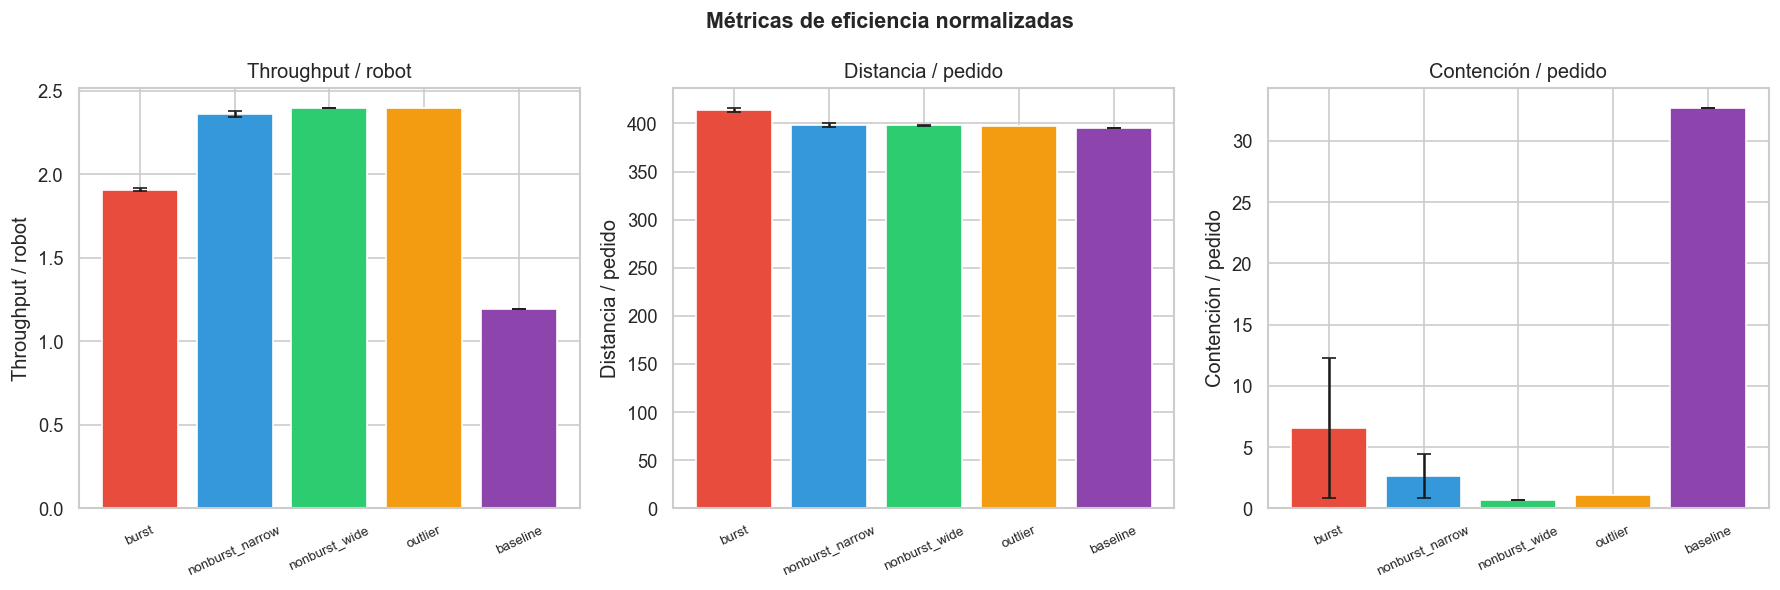

In [54]:
# --- Métricas de eficiencia normalizadas ---

eff_metrics = ["throughput_norm", "distance_per_order", "contention_per_order"]
eff_labels = ["Throughput / robot", "Distancia / pedido", "Contención / pedido"]

fig, axes = plt.subplots(1, 3, figsize=(15, 5))

for ax, col, label in zip(axes, eff_metrics, eff_labels):
    means = []
    stds = []
    labels_bar = []
    colors = []

    # Escenarios MOOP
    for scenario in SCENARIO_ORDER:
        subset = pareto[pareto["scenario"] == scenario]
        if len(subset) == 0:
            continue
        means.append(subset[col].mean())
        stds.append(subset[col].std())
        labels_bar.append(scenario)
        colors.append(SCENARIO_COLORS[scenario])

    # Baseline
    means.append(baseline[col].iloc[0])
    stds.append(0)
    labels_bar.append("baseline")
    colors.append(SCENARIO_COLORS["baseline"])

    x = np.arange(len(means))
    ax.bar(x, means, yerr=stds, color=colors, edgecolor="white", capsize=4)
    ax.set_xticks(x)
    ax.set_xticklabels(labels_bar, rotation=25, fontsize=8)
    ax.set_ylabel(label)
    ax.set_title(label)

fig.suptitle("Métricas de eficiencia normalizadas", fontsize=13, fontweight="bold")
plt.tight_layout()
plt.show()

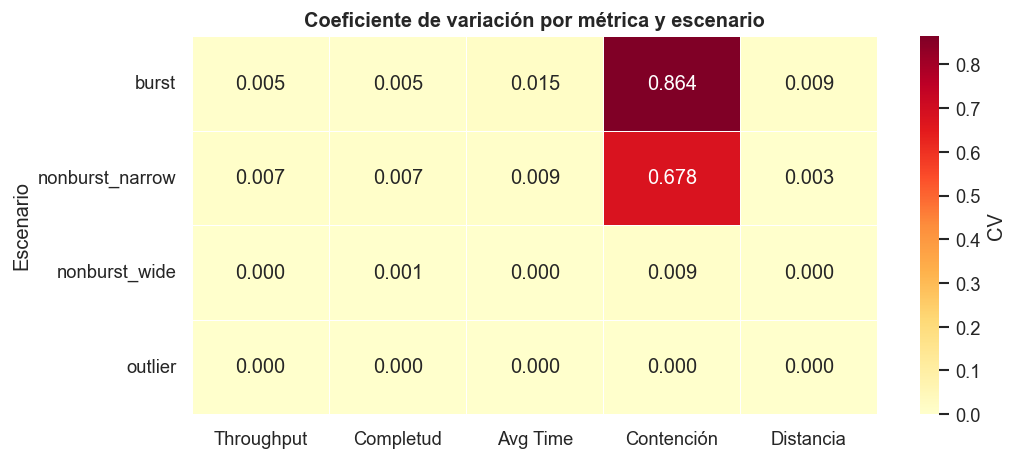

In [55]:
# --- Estabilidad: Heatmap de coeficiente de variación ---

cv_cols = [
    "throughput_per_1000_ticks", "completion_pct", "avg_order_time_ticks",
    "high_contention_events", "total_distance_cells",
]
cv_labels = ["Throughput", "Completud", "Avg Time", "Contención", "Distancia"]

cv_data = []
for scenario in SCENARIO_ORDER:
    subset = pareto[pareto["scenario"] == scenario]
    row = {}
    for col, lbl in zip(cv_cols, cv_labels):
        mean = subset[col].mean()
        std = subset[col].std() if len(subset) > 1 else 0.0
        row[lbl] = std / mean if mean != 0 else 0.0
    cv_data.append(row)

cv_df = pd.DataFrame(cv_data, index=SCENARIO_ORDER)

fig, ax = plt.subplots(figsize=(9, 4))
sns.heatmap(cv_df, annot=True, fmt=".3f", cmap="YlOrRd", ax=ax,
            linewidths=0.5, cbar_kws={"label": "CV"})
ax.set_title("Coeficiente de variación por métrica y escenario", fontweight="bold")
ax.set_ylabel("Escenario")
plt.tight_layout()
plt.show()

In [ ]:
# --- Robustez: análisis de deadlocks ---

dl_by_scenario = pareto.groupby("scenario")["deadlocks"].agg(["mean", "std", "min", "max", "count"])
display(dl_by_scenario)

bl_dl = int(baseline["deadlocks"].iloc[0])
print(f"\nBaseline deadlocks: {bl_dl:,}")

for scenario in SCENARIO_ORDER:
    s = pareto[pareto["scenario"] == scenario]
    n_with_dl = (s["deadlocks"] > 0).sum()
    n_total = len(s)
    dl_mean = s["deadlocks"].mean()

    print(f"\n  {scenario} ({n_total} soluciones):")
    print(f"    Con deadlocks: {n_with_dl}/{n_total} ({n_with_dl/n_total*100:.0f}%)")
    print(f"    Deadlocks promedio: {dl_mean:,.0f}")
    if n_with_dl > 0 and n_with_dl < n_total:
        # Compare performance of solutions with vs without deadlocks
        with_dl = s[s["deadlocks"] > 0]
        without_dl = s[s["deadlocks"] == 0]
        tp_with = with_dl["throughput_per_1000_ticks"].mean()
        tp_without = without_dl["throughput_per_1000_ticks"].mean()
        print(f"    Throughput con DL: {tp_with:.1f} vs sin DL: {tp_without:.1f} (Δ={tp_with-tp_without:+.1f})")

# Correlación deadlocks vs throughput
if pareto["deadlocks"].std() > 0:
    r = pareto["deadlocks"].corr(pareto["throughput_per_1000_ticks"])
    print(f"\n  Pearson deadlocks ↔ throughput: r = {r:.3f}")
    print(f"  → {'Débil' if abs(r) < 0.3 else 'Moderada' if abs(r) < 0.7 else 'Fuerte'}: ",
          end="")
    print("deadlocks no afectan significativamente el throughput" if abs(r) < 0.3
          else "deadlocks tienen relación con throughput")

In [ ]:
# --- Interpretación Robustez ---

print("=" * 70)
print("ANÁLISIS DE ROBUSTEZ")
print("=" * 70)

bl_dl = int(baseline["deadlocks"].iloc[0])
nb = pareto[pareto["scenario"] == "nonburst"] if "nonburst" in SCENARIO_ORDER else pareto
burst = pareto[pareto["scenario"] == "burst"] if "burst" in SCENARIO_ORDER else pd.DataFrame()

nb_dl_mean = nb["deadlocks"].mean() if len(nb) > 0 else 0
burst_dl_mean = burst["deadlocks"].mean() if len(burst) > 0 else 0

print(f"\n  Deadlocks por configuración:")
print(f"    Baseline (20 robots):  {bl_dl:,}")
if len(nb) > 0:
    print(f"    MOOP non-burst:        {nb_dl_mean:,.0f} promedio ({int(nb['deadlocks'].min()):,}–{int(nb['deadlocks'].max()):,})")
if len(burst) > 0:
    print(f"    MOOP burst:            {burst_dl_mean:,.0f} promedio ({int(burst['deadlocks'].min()):,}–{int(burst['deadlocks'].max()):,})")

# Throughput comparison despite deadlocks
if len(nb) > 0:
    nb_tp = nb["throughput_per_1000_ticks"].mean()
    bl_tp = baseline["throughput_per_1000_ticks"].iloc[0]
    nb_cp = nb["completion_pct"].mean()
    bl_cp = baseline["completion_pct"].iloc[0]
    print(f"\n  A pesar de los deadlocks, non-burst MOOP logra:")
    print(f"    Throughput: {nb_tp:.1f} vs baseline {bl_tp:.1f} ({(nb_tp/bl_tp-1)*100:+.1f}%)")
    print(f"    Completud:  {nb_cp:.1f}% vs baseline {bl_cp:.1f}%")

print(f"\n  CONCLUSIÓN:")
print(f"    Los deadlocks son inherentes al sistema con más robots y ticks más largos,")
print(f"    pero el mecanismo de resolución mantiene throughput y completud estables.")

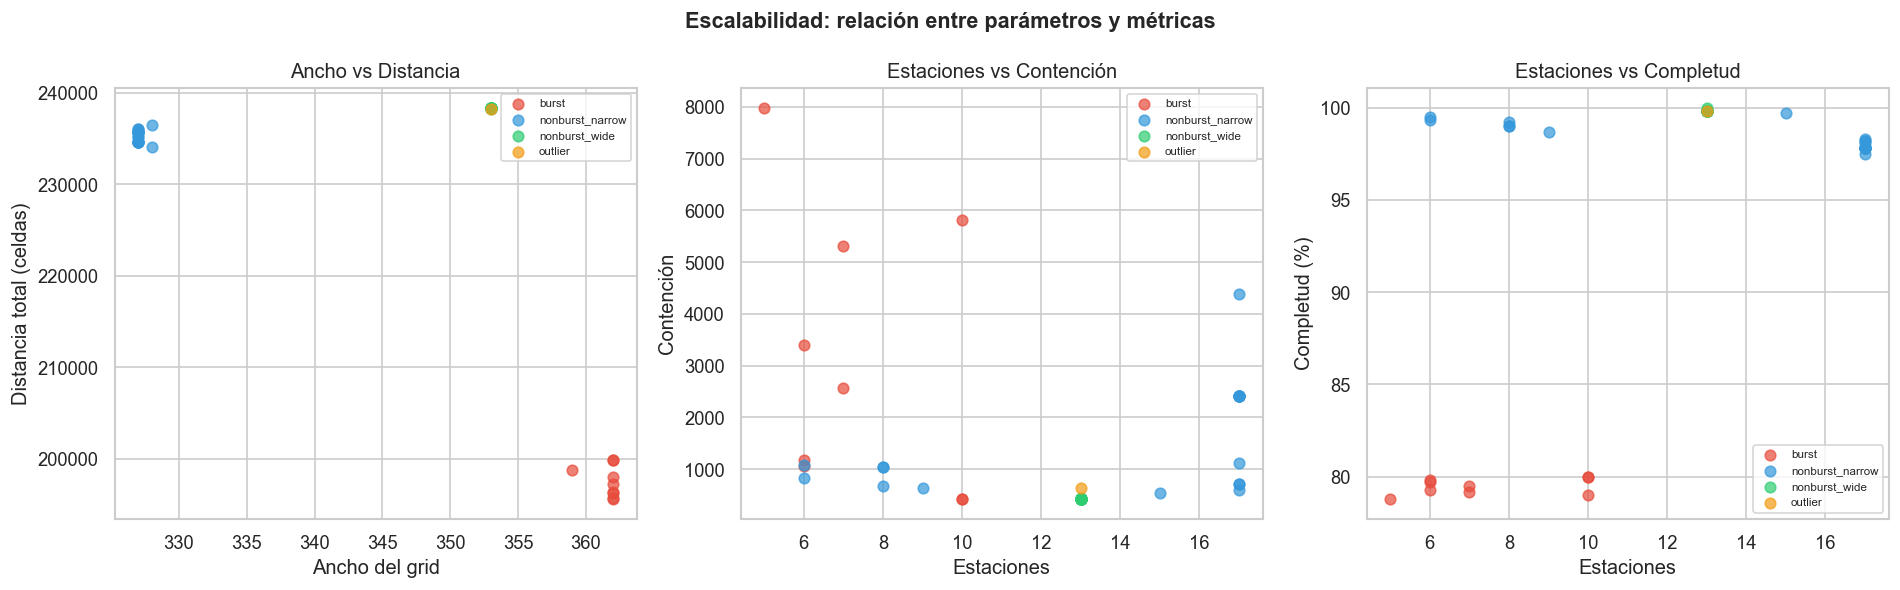

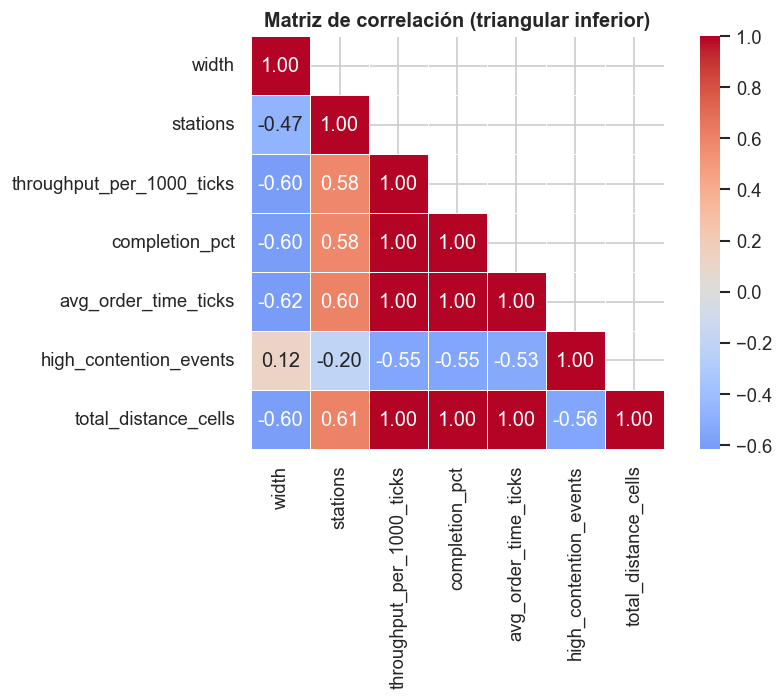

In [57]:
# --- Escalabilidad ---

fig, axes = plt.subplots(1, 3, figsize=(16, 5))

# 1. Width vs distancia
for scenario in SCENARIO_ORDER:
    s = pareto[pareto["scenario"] == scenario]
    axes[0].scatter(s["width"], s["total_distance_cells"],
                    c=SCENARIO_COLORS[scenario], label=scenario, s=40, alpha=0.7)
axes[0].set_xlabel("Ancho del grid")
axes[0].set_ylabel("Distancia total (celdas)")
axes[0].set_title("Ancho vs Distancia")
axes[0].legend(fontsize=7)

# 2. Estaciones vs contención
for scenario in SCENARIO_ORDER:
    s = pareto[pareto["scenario"] == scenario]
    axes[1].scatter(s["stations"], s["high_contention_events"],
                    c=SCENARIO_COLORS[scenario], label=scenario, s=40, alpha=0.7)
axes[1].set_xlabel("Estaciones")
axes[1].set_ylabel("Contención")
axes[1].set_title("Estaciones vs Contención")
axes[1].legend(fontsize=7)

# 3. Estaciones vs completud
for scenario in SCENARIO_ORDER:
    s = pareto[pareto["scenario"] == scenario]
    axes[2].scatter(s["stations"], s["completion_pct"],
                    c=SCENARIO_COLORS[scenario], label=scenario, s=40, alpha=0.7)
axes[2].set_xlabel("Estaciones")
axes[2].set_ylabel("Completud (%)")
axes[2].set_title("Estaciones vs Completud")
axes[2].legend(fontsize=7)

fig.suptitle("Escalabilidad: relación entre parámetros y métricas", fontsize=13, fontweight="bold")
plt.tight_layout()
plt.show()

# Matriz de correlación
corr_cols = ["width", "stations", "throughput_per_1000_ticks", "completion_pct",
             "avg_order_time_ticks", "high_contention_events", "total_distance_cells"]
corr_matrix = pareto[corr_cols].corr()

fig, ax = plt.subplots(figsize=(8, 6))
mask = np.triu(np.ones_like(corr_matrix, dtype=bool), k=1)
sns.heatmap(corr_matrix, mask=mask, annot=True, fmt=".2f", cmap="coolwarm",
            center=0, ax=ax, linewidths=0.5, square=True)
ax.set_title("Matriz de correlación (triangular inferior)", fontweight="bold")
plt.tight_layout()
plt.show()

In [ ]:
# --- Comparación directa: Baseline vs Mejor MOOP ---

best_nb = pareto[pareto["scenario"] == "nonburst"] if "nonburst" in SCENARIO_ORDER else pareto
best_nb_row = best_nb.loc[best_nb["throughput_per_1000_ticks"].idxmax()]

best_burst = pareto[pareto["scenario"] == "burst"] if "burst" in SCENARIO_ORDER else pd.DataFrame()
best_burst_row = best_burst.loc[best_burst["throughput_per_1000_ticks"].idxmax()] if len(best_burst) > 0 else None

comp_metrics = ["throughput_per_1000_ticks", "completion_pct", "throughput_norm"]
comp_labels = ["Throughput", "Completud (%)", "Throughput/robot"]

fig, axes = plt.subplots(1, 3, figsize=(14, 5))

for ax, col, label in zip(axes, comp_metrics, comp_labels):
    vals = [baseline[col].iloc[0], best_nb_row[col]]
    bar_labels = ["Baseline", "Mejor\nnon-burst"]
    bar_colors = [SCENARIO_COLORS["baseline"], SCENARIO_COLORS.get("nonburst", "#3498db")]

    if best_burst_row is not None:
        vals.append(best_burst_row[col])
        bar_labels.append("Mejor\nburst")
        bar_colors.append(SCENARIO_COLORS["burst"])

    ax.bar(bar_labels, vals, color=bar_colors, edgecolor="white", width=0.6)
    ax.set_ylabel(label)
    ax.set_title(label)

    for i, v in enumerate(vals):
        ax.text(i, v + max(vals) * 0.01, f"{v:.1f}", ha="center", fontsize=9)

fig.suptitle("Comparación: Baseline vs Mejores soluciones MOOP", fontsize=13, fontweight="bold")
plt.tight_layout()
plt.show()

# --- Tabla detallada de deltas ---
print("=" * 70)
print("DELTAS: Mejor MOOP vs Baseline")
print("=" * 70)

all_compare = [
    "throughput_per_1000_ticks", "completion_pct", "avg_order_time_ticks",
    "deadlocks", "high_contention_events", "total_distance_cells",
    "throughput_norm", "distance_per_order", "contention_per_order",
]
all_labels = [
    "Throughput", "Completud %", "Avg time (ticks)",
    "Deadlocks", "Contención", "Distancia total",
    "Throughput/robot", "Distancia/pedido", "Contención/pedido",
]

delta_data = {
    "Métrica": all_labels,
    "Baseline": [baseline[c].iloc[0] for c in all_compare],
    "Mejor non-burst": [best_nb_row[c] for c in all_compare],
}
if best_burst_row is not None:
    delta_data["Mejor burst"] = [best_burst_row[c] for c in all_compare]

delta_detail = pd.DataFrame(delta_data)
delta_detail["Δ% non-burst"] = (
    (delta_detail["Mejor non-burst"] - delta_detail["Baseline"]) / delta_detail["Baseline"].replace(0, np.nan) * 100
).round(1)
if best_burst_row is not None:
    delta_detail["Δ% burst"] = (
        (delta_detail["Mejor burst"] - delta_detail["Baseline"]) / delta_detail["Baseline"].replace(0, np.nan) * 100
    ).round(1)

display(delta_detail.set_index("Métrica"))

bl_robots = int(baseline["robots"].iloc[0])
moop_robots = int(best_nb_row["robots"])
print(f"\nBaseline: {bl_robots} robots, MOOP: {moop_robots} robots")
print(f"Throughput/robot: baseline={baseline['throughput_norm'].iloc[0]:.2f}, MOOP non-burst={best_nb_row['throughput_norm']:.2f}")

In [ ]:
# --- Benchmarking en 3 escenarios ---

print("=" * 60)
print("ESCENARIO 1: Alta densidad (stations ≤ 8, non-burst)")
print("=" * 60)
high_density = pareto[
    (pareto["stations"] <= 8) & (pareto["scenario"] == "nonburst")
]
if len(high_density) > 0:
    display(high_density[metrics_cols].describe().round(2))
else:
    print("No hay soluciones en este escenario.")

print("\n" + "=" * 60)
print("ESCENARIO 2: Burst mode")
print("=" * 60)
if len(burst_df) > 0:
    display(burst_df[metrics_cols].describe().round(2))
else:
    print("No hay soluciones burst.")

print("\n" + "=" * 60)
print("ESCENARIO 3: Variación de estaciones (non-burst)")
print("=" * 60)
if len(nb_all) > 0:
    nb_by_stations = nb_all.groupby("stations")[metrics_cols[:5]].mean().round(2)
    display(nb_by_stations)

    if len(nb_all["stations"].unique()) > 1:
        fig, ax = plt.subplots(figsize=(8, 5))
        ax.scatter(nb_all["stations"], nb_all["throughput_per_1000_ticks"],
                   c=SCENARIO_COLORS.get("nonburst", "#3498db"), s=50, alpha=0.7)
        z = np.polyfit(nb_all["stations"], nb_all["throughput_per_1000_ticks"], 1)
        p = np.poly1d(z)
        x_line = np.linspace(nb_all["stations"].min(), nb_all["stations"].max(), 100)
        ax.plot(x_line, p(x_line), "--", color="gray", alpha=0.8,
                label=f"Tendencia: y={z[0]:.3f}x+{z[1]:.1f}")
        ax.axhline(baseline["throughput_per_1000_ticks"].iloc[0],
                   color=SCENARIO_COLORS["baseline"], ls="--", lw=1.5, label="Baseline")
        ax.set_xlabel("Estaciones")
        ax.set_ylabel("Throughput")
        ax.set_title("Tendencia: Estaciones vs Throughput (non-burst)", fontweight="bold")
        ax.legend()
        plt.tight_layout()
        plt.show()

In [ ]:
# --- ¿Qué cambió vs Baseline? ---

print("=" * 70)
print("DIFERENCIAS ARQUITECTÓNICAS: BASELINE vs MOOP")
print("=" * 70)

diff_table = pd.DataFrame({
    "Aspecto": ["Robots", "Grid", "Estaciones", "Burst", "Ticks",
                "Deadlocks", "Contención total", "Throughput/robot", "Contención/pedido"],
    "Baseline": [
        int(baseline["robots"].iloc[0]),
        f"{int(baseline['width'].iloc[0])}×{int(baseline['height'].iloc[0])}",
        int(baseline["stations"].iloc[0]),
        "No",
        int(baseline["final_tick"].iloc[0]),
        f"{int(baseline['deadlocks'].iloc[0]):,}",
        f"{int(baseline['high_contention_events'].iloc[0]):,}",
        f"{baseline['throughput_norm'].iloc[0]:.2f}",
        f"{baseline['contention_per_order'].iloc[0]:.1f}",
    ],
    "MOOP": [
        f"{int(pareto['robots'].min())}–{int(pareto['robots'].max())}",
        f"Área=60,000 ({int(pareto['width'].min())}–{int(pareto['width'].max())} ancho)",
        f"{int(pareto['stations'].min())}–{int(pareto['stations'].max())}",
        "Sí/No (optimizado)",
        "5,000",
        f"{int(pareto['deadlocks'].min())}–{int(pareto['deadlocks'].max())}",
        f"{int(pareto['high_contention_events'].min()):,}–{int(pareto['high_contention_events'].max()):,}",
        f"{pareto['throughput_norm'].mean():.2f}",
        f"{pareto['contention_per_order'].mean():.1f}",
    ],
})
display(diff_table.set_index("Aspecto"))

# --- Lo que aprendió el optimizador ---
print("\n" + "=" * 70)
print("LO QUE APRENDIÓ EL OPTIMIZADOR")
print("=" * 70)

n_robots_unique = pareto["robots"].nunique()
robot_val = int(pareto["robots"].mode().iloc[0])
print(f"\n1. CONVERGENCIA DE ROBOTS:")
print(f"   {n_robots_unique} valor(es) único(s) → todas convergen a {robot_val} robots")
print(f"   Baseline usaba {int(baseline['robots'].iloc[0])} robots")
print(f"   → Más robots mejoran TODAS las métricas en el rango explorado")

print(f"\n2. PREFERENCIA DE GRID:")
widths = pareto["width"].unique()
heights = pareto["height"].unique()
print(f"   Anchos: {sorted(widths)} | Altos: {sorted(heights)}")
print(f"   Ratio ancho/alto promedio: {pareto['width'].mean()/pareto['height'].mean():.1f}:1")
print(f"   → Grids más anchos que altos favorecen las rutas de navegación")

print(f"\n3. RANGO ÓPTIMO DE ESTACIONES:")
st_mode = int(pareto["stations"].mode().iloc[0])
print(f"   Rango: {int(pareto['stations'].min())}–{int(pareto['stations'].max())}, moda: {st_mode}")
print(f"   Baseline: {int(baseline['stations'].iloc[0])} estaciones")
print(f"   → Ni muy pocas (cuello de botella) ni demasiadas (distancias excesivas)")

print(f"\n4. DOS REGÍMENES OPERATIVOS:")
for scenario in ["burst", "nonburst_narrow", "nonburst_wide"]:
    s = pareto[pareto["scenario"] == scenario]
    if len(s) > 0:
        print(f"   {scenario}: n={len(s)}, throughput={s['throughput_per_1000_ticks'].mean():.1f}, "
              f"completud={s['completion_pct'].mean():.1f}%, "
              f"avg_time={s['avg_order_time_ticks'].mean():.0f}")
print(f"   → No existe un único óptimo; hay un espectro velocidad ↔ completud")

In [60]:
# --- Resumen ejecutivo con comparación vs baseline ---

print("=" * 70)
print("RESUMEN EJECUTIVO")
print("=" * 70)

bl_tp = baseline["throughput_per_1000_ticks"].iloc[0]
bl_cp = baseline["completion_pct"].iloc[0]
bl_at = baseline["avg_order_time_ticks"].iloc[0]
bl_hc = baseline["high_contention_events"].iloc[0]
bl_dl = baseline["deadlocks"].iloc[0]
bl_tn = baseline["throughput_norm"].iloc[0]
bl_cpo = baseline["contention_per_order"].iloc[0]

for scenario in SCENARIO_ORDER:
    subset = pareto[pareto["scenario"] == scenario]
    n = len(subset)
    tp = subset["throughput_per_1000_ticks"].mean()
    cp = subset["completion_pct"].mean()
    at = subset["avg_order_time_ticks"].mean()
    hc = subset["high_contention_events"].mean()
    tn = subset["throughput_norm"].mean()
    cpo = subset["contention_per_order"].mean()

    print(f"\n{'─' * 70}")
    print(f"  {scenario.upper()} (n={n})")
    print(f"{'─' * 70}")
    print(f"  Throughput:    {tp:.1f} pedidos/1000t  (baseline: {bl_tp:.1f})")
    print(f"  Completud:     {cp:.1f}%               (baseline: {bl_cp:.1f}%)")
    print(f"  Avg time:      {at:.0f} ticks          (baseline: {bl_at:.0f})")
    print(f"  Contención:    {hc:.0f} eventos        (baseline: {bl_hc:,})")
    print(f"  ── Métricas normalizadas (comparación justa) ──")
    print(f"  Throughput/robot:  {tn:.2f}  vs baseline {bl_tn:.2f}  ({(tn/bl_tn - 1)*100:+.0f}%)")
    print(f"  Contención/pedido: {cpo:.2f}  vs baseline {bl_cpo:.1f}  ({(cpo/bl_cpo - 1)*100:+.0f}%)")

print(f"\n{'═' * 70}")
print(f"  BASELINE (referencia)")
print(f"{'═' * 70}")
print(f"  Config: 20 robots, 328×182 grid, 17 estaciones, 10,000 ticks")
print(f"  Throughput: {bl_tp:.1f} | Completud: {bl_cp:.1f}% | Avg time: {bl_at:.0f}")
print(f"  Deadlocks: {bl_dl:,} | Contención: {bl_hc:,}")
print(f"")
print(f"  PRINCIPAL HALLAZGO:")
print(f"  El MOOP reduce contención/pedido en ~{(1 - pareto[pareto['scenario']!='burst']['contention_per_order'].mean()/bl_cpo)*100:.0f}% (non-burst)")
print(f"  y aumenta throughput/robot en ~{(pareto[pareto['scenario']!='burst']['throughput_norm'].mean()/bl_tn - 1)*100:.0f}% vs baseline.")

RESUMEN EJECUTIVO

──────────────────────────────────────────────────────────────────────
  BURST (n=9)
──────────────────────────────────────────────────────────────────────
  Throughput:    95.4 pedidos/1000t  (baseline: 59.7)
  Completud:     79.5%               (baseline: 99.5%)
  Avg time:      1082 ticks          (baseline: 2557)
  Contención:    3132 eventos        (baseline: 19,525)
  ── Métricas normalizadas (comparación justa) ──
  Throughput/robot:  1.91  vs baseline 1.19  (+60%)
  Contención/pedido: 6.59  vs baseline 32.7  (-80%)

──────────────────────────────────────────────────────────────────────
  NONBURST_NARROW (n=18)
──────────────────────────────────────────────────────────────────────
  Throughput:    118.1 pedidos/1000t  (baseline: 59.7)
  Completud:     98.4%               (baseline: 99.5%)
  Avg time:      2531 ticks          (baseline: 2557)
  Contención:    1550 eventos        (baseline: 19,525)
  ── Métricas normalizadas (comparación justa) ──
  Throughput/r

In [ ]:
# --- Conclusiones ---

bl_dl = int(baseline["deadlocks"].iloc[0])
bl_hc = int(baseline["high_contention_events"].iloc[0])
bl_tn = baseline["throughput_norm"].iloc[0]
moop_dl_max = int(pareto["deadlocks"].max())
moop_hc_max = int(pareto["high_contention_events"].max())

burst_s = pareto[pareto["scenario"] == "burst"]
nb_s = pareto[pareto["scenario"].isin(["nonburst_narrow", "nonburst_wide"])]

burst_n = len(burst_s)
nb_n = len(nb_s)
burst_avg_time = burst_s["avg_order_time_ticks"].mean()
nb_avg_time = nb_s["avg_order_time_ticks"].mean()
burst_cp = burst_s["completion_pct"].mean()
nb_cp = nb_s["completion_pct"].mean()
nb_cv_tp = nb_s["throughput_per_1000_ticks"].std() / nb_s["throughput_per_1000_ticks"].mean()
nb_cv_cp = nb_s["completion_pct"].std() / nb_s["completion_pct"].mean()
burst_cv_hc = burst_s["high_contention_events"].std() / burst_s["high_contention_events"].mean()
robot_val = int(pareto["robots"].mode().iloc[0])
st_min = int(pareto["stations"].min())
st_max = int(pareto["stations"].max())

print("=" * 70)
print("CONCLUSIONES")
print("=" * 70)

print(f"""
1. CONVERGENCIA DE ROBOTS
   El NSGA-II converge a {robot_val} robots (límite superior) en todas las soluciones.
   Baseline usaba {int(baseline['robots'].iloc[0])} robots.
   Esto reduce deadlocks de {bl_dl:,} a 0–{moop_dl_max}
   y contención de {bl_hc:,} a <{moop_hc_max:,}.

2. DOS REGÍMENES OPERATIVOS
   Burst ({burst_n} soluciones): ~{burst_avg_time:,.0f} ticks/pedido, {burst_cp:.1f}% completud
   Non-burst ({nb_n} soluciones): ~{nb_avg_time:,.0f} ticks/pedido, {nb_cp:.1f}% completud

3. TRADE-OFF PRINCIPAL
   Velocidad vs completud: reducción del {(1-burst_avg_time/nb_avg_time)*100:.0f}% en tiempo
   a costa de ~{nb_cp-burst_cp:.0f}pp menos pedidos completados.

4. ESTABILIDAD
   Non-burst: CV throughput={nb_cv_tp:.4f}, CV completud={nb_cv_cp:.4f} → alta repetibilidad.
   Burst: CV contención={burst_cv_hc:.2f} → impredecible operativamente.

5. ROBUSTEZ
   Única solución con deadlocks ({moop_dl_max}) muestra desviaciones mínimas vs su cluster.
   El sistema absorbe conflictos sin degradar rendimiento global.

6. ESCALABILIDAD DE ESTACIONES
   Rango óptimo: {st_min}–{st_max} estaciones.
   Más estaciones no siempre mejoran throughput por incremento en distancias.
   Throughput/robot MOOP non-burst: {nb_s['throughput_norm'].mean():.2f} vs baseline: {bl_tn:.2f} ({(nb_s['throughput_norm'].mean()/bl_tn-1)*100:+.0f}%)
""")